In [ ]:
import sys
import os
from os import path as osp
import pandas as pd
import numpy as np
import json
from pprint import pprint
from glob import glob

sys.path.append('../')

from analysis_utils import prepare_data
from data_utils import get_unique_cells, parse_json_string, unique_cells_iou, plot_target_with_speaker_order

REF_ANN_PATH = os.path.realpath(
    "../color-grid-segment-annotations/data/processed_annotations/consensus_majority_clean.json"
)  # preprocessed annotations for this project
COLORGRID_ANN_PATH = os.path.realpath(
    "../color-grid-segment-annotations/data/color_grid_data.json"
)  # original annotations (formatted)
LS_DATA_PATH = os.path.realpath(
    "../color-grid-segment-annotations/data/label_studio_input/label_studio_input.json"
)  # label studio inputs

MODEL_ANNOTATION_DIR = os.path.realpath('../output/generated_annotations')
        
INTERMEDIATE_RESULTS_DIR = os.path.abspath('../output/intermediate_results')
print(f"Intermediate results will be saved to: {INTERMEDIATE_RESULTS_DIR}")
os.makedirs(INTERMEDIATE_RESULTS_DIR, exist_ok=True)

In [2]:
ann_df, data_df, gameids, (far_ids, split_ids, close_ids) = prepare_data(REF_ANN_PATH, COLORGRID_ANN_PATH, LS_DATA_PATH)

read ann data...
read source data...
add further information from label studio data...


# Parse Model Annotations

In [3]:
available_files = sorted(glob(osp.join(MODEL_ANNOTATION_DIR, "*.json")))
print(*[osp.split(f)[-1] for f in available_files], sep="\n")

Qwen36-35B-A3B-FP8_Qwen35-27B-FP8-thinking_annotations.json
Qwen36-35B-A3B-FP8_Qwen35-27B-FP8_annotations.json
Qwen36-35B-A3B-FP8_Qwen35-4B-thinking_annotations.json
Qwen36-35B-A3B-FP8_Qwen35-4B_annotations.json
Qwen36-35B-A3B-FP8_Qwen35-9B-thinking_annotations.json
Qwen36-35B-A3B-FP8_Qwen35-9B_annotations.json
Qwen36-35B-A3B-FP8_Qwen36-27B-FP8-thinking_annotations.json
Qwen36-35B-A3B-FP8_Qwen36-27B-FP8_annotations.json
Qwen36-35B-A3B-FP8_full_human_annotations.json
Qwen36-35B-A3B-FP8_gemma-4-12B-it-thinking_annotations.json
Qwen36-35B-A3B-FP8_gemma-4-12B-it_annotations.json
Qwen36-35B-A3B-FP8_gemma-4-26B-A4B-it-FP8-Dynamic-thinking_annotations.json
Qwen36-35B-A3B-FP8_gemma-4-26B-A4B-it-FP8-Dynamic_annotations.json
Qwen36-35B-A3B-FP8_gemma-4-E4B-it-thinking_annotations.json
Qwen36-35B-A3B-FP8_gemma-4-E4B-it_annotations.json


In [4]:
for file in available_files:

    # read file and extract relevant information
    filepath = osp.join(MODEL_ANNOTATION_DIR, file)
    with open(filepath, "r") as f:
        file_content = json.load(f)

    model_id = file_content.get("model_id")
    evaluated_system = osp.split(file_content.get("evaluated_system"))[-1]
    evaluated_enable_thinking = file_content.get("evaluated_enable_thinking")
    evaluated_model_label = evaluated_system + (
        "-thinking" if evaluated_enable_thinking else ""
    )

    # parse model responses and extract error entries
    response_df = pd.DataFrame(file_content["responses"]).set_index("target_id")
    response_df["model_response"] = response_df.model_response.map(parse_json_string)
    # items with reported errors (e.g., API timeouts, etc.)
    error_report_entries = response_df[~response_df.error_type.isna()]
    n_reported_error_entries = len(error_report_entries)
    # items with missing data (i.e., where "no_reference" cannot be retrieved correctly)
    missing_entries = response_df[
        response_df.model_response.map(
            lambda x: x.get("no_reference") if x else pd.NA
        ).isna()  # default to NA if no_reference cannot be retrieved, and filter for those entries
    ]
    n_missing_entries = len(missing_entries)
    # combine both error cases and remove duplicates
    error_entries = pd.concat([error_report_entries, missing_entries])
    error_entries = error_entries[~error_entries.index.duplicated()]
    n_error_entries = len(error_entries)

### Basic Stats

In [5]:
stats_df = pd.DataFrame(
    columns=pd.MultiIndex.from_tuples([], names=["system", "enable_thinking"])
)
cells_per_targets = pd.DataFrame(
    columns=pd.MultiIndex.from_tuples([], names=["system", "enable_thinking"])
)

for file in available_files:

    # read file and extract relevant information
    filepath = osp.join(MODEL_ANNOTATION_DIR, file)
    with open(filepath, "r") as f:
        file_content = json.load(f)

    model_id = file_content.get("model_id")
    evaluated_system = osp.split(file_content.get("evaluated_system"))[-1]
    evaluated_enable_thinking = file_content.get("evaluated_enable_thinking")
    evaluated_model_label = evaluated_system + (
        "-thinking" if evaluated_enable_thinking else ""
    )

    # parse model responses and extract error entries
    response_df = pd.DataFrame(file_content["responses"]).set_index("target_id")
    response_df["model_response"] = response_df.model_response.map(parse_json_string)
    # items with reported errors (e.g., API timeouts, etc.)
    error_report_entries = response_df[~response_df.error_type.isna()]
    n_reported_error_entries = len(error_report_entries)
    # items with missing data (i.e., where "no_reference" cannot be retrieved correctly)
    missing_entries = response_df[
        response_df.model_response.map(
            lambda x: x.get("no_reference") if x else pd.NA
        ).isna()  # default to NA if no_reference cannot be retrieved, and filter for those entries
    ]
    n_missing_entries = len(missing_entries)
    # combine both error cases and remove duplicates
    error_entries = pd.concat([error_report_entries, missing_entries])
    error_entries = error_entries[~error_entries.index.duplicated()]
    n_error_entries = len(error_entries)

    # restrict to valid entries (i.e., those that are not error cases)
    valid_entries = response_df[~response_df.index.isin(error_entries.index)]

    # select no_reference entries (model indicates that descriptions cannot be mapped to target cells)
    no_reference_mask = valid_entries.model_response.map(
        lambda x: x.get("no_reference")
    )
    no_reference_entries = valid_entries[no_reference_mask.fillna(False)]
    n_no_reference = len(no_reference_entries)

    # exclude no_reference entries for further analysis
    reference_entries = valid_entries[~no_reference_mask.fillna(False)]

    # compute average number of unique target cells per description
    reference_entries["unique_target_cells"] = reference_entries.model_response.map(
        get_unique_cells
    )
    avg_len = reference_entries.unique_target_cells.map(len).mean().item()

    # collect cells per targets for cross-system comparison
    cells_per_targets[(evaluated_system, evaluated_enable_thinking)] = (
        reference_entries.unique_target_cells
    )

    # store stats in dataframe
    stats_df[(evaluated_system, evaluated_enable_thinking)] = pd.Series(
        {
            "reported_error_entries": n_reported_error_entries / len(response_df),
            "missing_entries": n_missing_entries / len(response_df),
            "error_entries": n_error_entries / len(response_df),
            "no_reference": n_no_reference / len(valid_entries),
            "avg_len": avg_len,
        }
    )

# transpose and transform percentages
stats_df = stats_df.T.sort_index()
perc_cols = [
    "reported_error_entries",
    "missing_entries",
    "error_entries",
    "no_reference",
]
stats_df[perc_cols] = stats_df[perc_cols] * 100

### IOU with human descriptions

In [6]:
systems = [c for c in cells_per_targets.columns if c[0] != 'human']

iou_results = {}
for system in systems:
    s1 = cells_per_targets[system]
    s2 = cells_per_targets[('human', np.nan)]
    iou_results[system] = unique_cells_iou(s1, s2)
    
stats_df['iou_with_human'] = pd.Series(iou_results)

In [7]:
stats_df

reported_error_entries  \
system                         enable_thinking                           
Qwen3.5-27B-FP8                False                          0.200000   
                               True                           1.400000   
Qwen3.5-4B                     False                          0.200000   
                               True                           0.866667   
Qwen3.5-9B                     False                          0.200000   
                               True                           2.200000   
Qwen3.6-27B-FP8                False                          0.200000   
                               True                           0.933333   
gemma-4-12B-it                 False                          0.200000   
                               True                           2.733333   
gemma-4-26B-A4B-it-FP8-Dynamic False                          0.200000   
                               True                           4.200000   
gemma-4-E4B-it                 False                          0.200000   
                               True                           0.200000   
human                          NaN                            0.000000   

                                                missing_entries  \
system                         enable_thinking                    
Qwen3.5-27B-FP8                False                   0.200000   
                               True                    1.400000   
Qwen3.5-4B                     False                   0.200000   
                               True                    0.866667   
Qwen3.5-9B                     False                   0.333333   
                               True                    2.200000   
Qwen3.6-27B-FP8                False                   0.200000   
                               True                    1.000000   
gemma-4-12B-it                 False                   0.200000   
                               True                    2.733333   
gemma-4-26B-A4B-it-FP8-Dynamic False                   0.200000   
                               True                    4.200000   
gemma-4-E4B-it                 False                   0.800000   
                               True                    0.200000   
human                          NaN                     0.000000   

                                                error_entries  no_reference  \
system                         enable_thinking                                
Qwen3.5-27B-FP8                False                 0.200000      0.801603   
                               True                  1.400000      0.000000   
Qwen3.5-4B                     False                 0.200000     27.722111   
                               True                  0.866667      6.254203   
Qwen3.5-9B                     False                 0.333333      0.802676   
                               True                  2.200000      0.136333   
Qwen3.6-27B-FP8                False                 0.200000      2.137609   
                               True                  1.000000      0.202020   
gemma-4-12B-it                 False                 0.200000      0.000000   
                               True                  2.733333      0.068540   
gemma-4-26B-A4B-it-FP8-Dynamic False                 0.200000      0.668003   
                               True                  4.200000      0.069589   
gemma-4-E4B-it                 False                 0.800000      1.142473   
                               True                  0.200000      1.670007   
human                          NaN                   0.000000      0.000000   

                                                 avg_len  iou_with_human  
system                         enable_thinking                            
Qwen3.5-27B-FP8                False            1.565657        0.395458  
                               True             2.218391        0.361038  
Qwen3

### Present Results

In [8]:
present_stats_df = stats_df.reset_index()

system_map = {
"human": "human",
"Qwen3.6-27B-FP8": "Qwen3.6-27B",
"Qwen3.5-4B": "Qwen3.5-4B",
"Qwen3.5-9B": "Qwen3.5-9B",
"Qwen3.5-27B-FP8": "Qwen3.5-27B",
"gemma-4-E4B-it": "gemma-4-E4B-it",
"gemma-4-12B-it": "gemma-4-12B-it",
"gemma-4-26B-A4B-it-FP8-Dynamic": "gemma-4-26B-A4B-it",
}

# set architecture as categorical with a specific order
system_cat_type = pd.CategoricalDtype(
    categories=[
        "human",
        "Qwen3.6-27B",
        "Qwen3.5-4B",
        "Qwen3.5-9B",
        "Qwen3.5-27B",
        "gemma-4-E4B-it",
        "gemma-4-12B-it",
        "gemma-4-26B-A4B-it",
    ],
    ordered=True,
)
present_stats_df["system"] = present_stats_df.system.map(system_map)
present_stats_df["system"] = present_stats_df.system.astype(system_cat_type)

# restrict to relevant columns and set multiindex
selected_cols = ['system', 'enable_thinking', 'error_entries','no_reference', 'avg_len', 'iou_with_human']
present_stats_df = present_stats_df[selected_cols]
present_stats_df = present_stats_df.set_index(['system', 'enable_thinking']).sort_index(ascending=[True, False])

# dict for renaming columns
rename_cols = {
    "system": "architecture",
    "enable_thinking": "thinking",
    "error_entries": "errors (%)",
    "no_reference": "no reference (%)",
    "avg_len": "cells mentioned",
    "iou_with_human": "IOU / human",
}

In [9]:
present_stats_df.rename(columns=rename_cols).round(2)

errors (%)  no reference (%)  \
system             enable_thinking                                 
human              NaN                    0.00              0.00   
Qwen3.6-27B        True                   1.00              0.20   
                   False                  0.20              2.14   
Qwen3.5-4B         True                   0.87              6.25   
                   False                  0.20             27.72   
Qwen3.5-9B         True                   2.20              0.14   
                   False                  0.33              0.80   
Qwen3.5-27B        True                   1.40              0.00   
                   False                  0.20              0.80   
gemma-4-E4B-it     True                   0.20              1.67   
                   False                  0.80              1.14   
gemma-4-12B-it     True                   2.73              0.07   
                   False                  0.20              0.00   
gemma-4-26B-A4B-it True                   4.20              0.07   
                   False                  0.20              0.67   

                                    cells mentioned  IOU / human  
system             enable_thinking                                
human              NaN                         1.63          NaN  
Qwen3.6-27B        True                        2.21         0.37  
                   False                       1.88         0.39  
Qwen3.5-4B         True                        8.45         0.20  
                   False                       8.74         0.19  
Qwen3.5-9B         True                        4.97         0.29  
                   False                       3.67         0.29  
Qwen3.5-27B        True                        2.22         0.36  
                   False                       1.57         0.40  
gemma-4-E4B-it     True                        4.19         0.27  
                   False                       7.27         0.19  
gemma-4-12B-it     True                        7.88         0.22  
                   False                       8.84         0.19  
gemma-4-26B-A4B-it True                        8.48         0.20  
                   False                       7.82         0.21

In [10]:
print(
    present_stats_df.reset_index()
    .rename(columns=rename_cols)
    .round(2)
    .fillna("-")
    .to_latex(index=False, escape=True, float_format="%.2f", column_format="llrrrr")
)

\begin{tabular}{llrrrr}
\toprule
architecture & thinking & errors (\%) & no reference (\%) & cells mentioned & IOU / human \\
\midrule
human & - & 0.00 & 0.00 & 1.63 & - \\
Qwen3.6-27B & True & 1.00 & 0.20 & 2.21 & 0.37 \\
Qwen3.6-27B & False & 0.20 & 2.14 & 1.88 & 0.39 \\
Qwen3.5-4B & True & 0.87 & 6.25 & 8.45 & 0.20 \\
Qwen3.5-4B & False & 0.20 & 27.72 & 8.74 & 0.19 \\
Qwen3.5-9B & True & 2.20 & 0.14 & 4.97 & 0.29 \\
Qwen3.5-9B & False & 0.33 & 0.80 & 3.67 & 0.29 \\
Qwen3.5-27B & True & 1.40 & 0.00 & 2.22 & 0.36 \\
Qwen3.5-27B & False & 0.20 & 0.80 & 1.57 & 0.40 \\
gemma-4-E4B-it & True & 0.20 & 1.67 & 4.19 & 0.27 \\
gemma-4-E4B-it & False & 0.80 & 1.14 & 7.27 & 0.19 \\
gemma-4-12B-it & True & 2.73 & 0.07 & 7.88 & 0.22 \\
gemma-4-12B-it & False & 0.20 & 0.00 & 8.84 & 0.19 \\
gemma-4-26B-A4B-it & True & 4.20 & 0.07 & 8.48 & 0.20 \\
gemma-4-26B-A4B-it & False & 0.20 & 0.67 & 7.82 & 0.21 \\
\bottomrule
\end{tabular}



# Qualitative Examples

In [11]:
model_response_df = pd.DataFrame()

for file in available_files:
    filepath = osp.join(MODEL_ANNOTATION_DIR, file)
    with open(filepath, "r") as f:
        file_content = json.load(f)

    model_id = file_content.get("model_id")
    evaluated_system = osp.split(file_content.get("evaluated_system"))[-1]
    evaluated_enable_thinking = file_content.get("evaluated_enable_thinking")
    evaluated_model_label = evaluated_system + (
        "-thinking" if evaluated_enable_thinking else ""
    )

    response_df = pd.DataFrame(file_content["responses"]).set_index("target_id")
    response_df["model_response"] = response_df.model_response.map(parse_json_string)
    response_df[f"unique_cells"] = response_df.model_response.map(get_unique_cells)
    
    if evaluated_system == "human":
        model_response_df[f"{evaluated_model_label}_description"] = ann_df.groupby('round_id').first().full_text
    else:
        model_response_df[f"{evaluated_model_label}_description"] = response_df.description
    model_response_df[f"{evaluated_model_label}_response"] = response_df.model_response
    model_response_df[f"{evaluated_model_label}_cells"] = response_df.unique_cells

In [12]:
model_response_df.reset_index().to_json(os.path.join(INTERMEDIATE_RESULTS_DIR, "automatic_anns_per_item.json"), orient="records")

In [13]:
INCLUDED_SYSTEMS = [
    "human",
    # "Qwen3.6-27B-FP8",
    # "Qwen3.6-27B-FP8-thinking",
    "Qwen3.5-4B",
    "Qwen3.5-4B-thinking",
    # "Qwen3.5-9B",
    # "Qwen3.5-9B-thinking",
    "Qwen3.5-27B-FP8",
    "Qwen3.5-27B-FP8-thinking",
    #"gemma-4-E4B-it",
    #"gemma-4-E4B-it-thinking",
    # "gemma-4-12B-it",
    # "gemma-4-12B-it-thinking",
    #"gemma-4-26B-A4B-it-FP8-Dynamic",
    #"gemma-4-26B-A4B-it-FP8-Dynamic-thinking",
]

def display_sample(round_id, examples=model_response_df, included_systems=INCLUDED_SYSTEMS, data_df=data_df):
    
    round_entries = examples.loc[round_id]
    print(f"Round ID: {round_id}")
    display(plot_target_with_speaker_order(round_id, data_df=data_df))
    
    for system in included_systems:
        description_col = f"{system}_description"
        cells_col = f"{system}_cells"
        
        description = round_entries[description_col]
        cells = round_entries[cells_col]
        cells = sorted(cells) if isinstance(cells, set) else cells       
        
        pprint(f"System: {system}")
        pprint(f"Description: {description}")
        pprint(f"Cells: {cells}")
        print("\n")

Round ID: 2589-050e0f91-7dba-48c6-b219-c1d2a9b4eb39_9


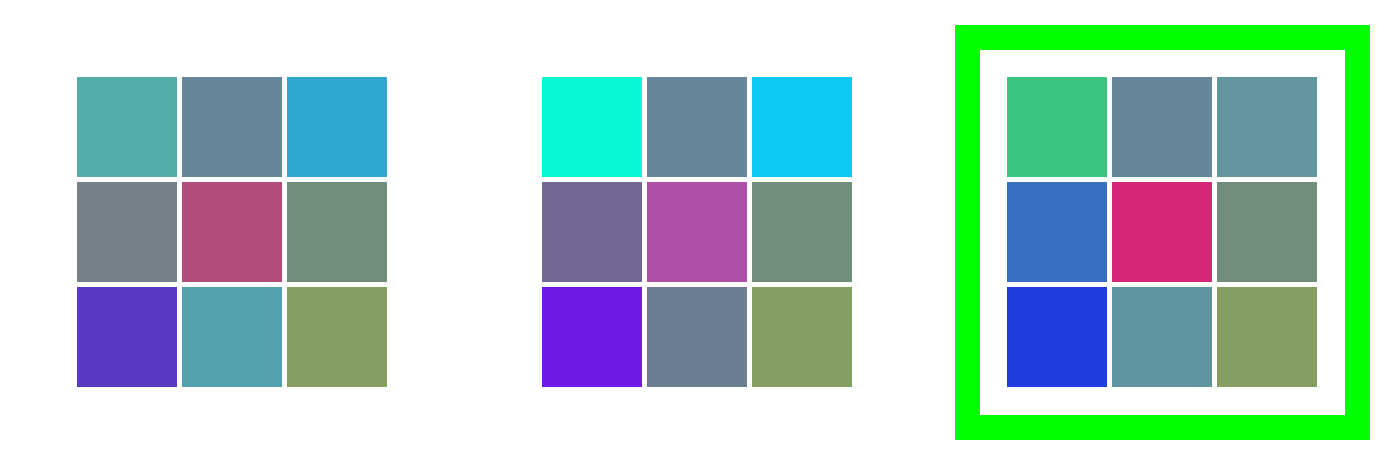

'System: human'
'Description: speaker: brightest pink middle'
"Cells: ['t5']"


'System: Qwen3.5-4B'
('Description: A 3x3 grid of colored squares with a thick white border '
 'surrounding it.')
'Cells: None'


'System: Qwen3.5-4B-thinking'
('Description: A 3x3 grid with a thick green border. Top row: green, '
 'grey-blue, teal. Middle row: blue, magenta, grey-green. Bottom row: dark '
 'blue, teal, olive green.')
"Cells: ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9']"


'System: Qwen3.5-27B-FP8'
('Description: The grid with a bright pink center square and a dark blue '
 'square in the bottom left corner.')
"Cells: ['t5', 't7']"


'System: Qwen3.5-27B-FP8-thinking'
('Description: The grid with a green square in the top left corner and a dark '
 'blue square in the bottom left corner.')
"Cells: ['t1', 't7']"




In [14]:
target_id = "2589-050e0f91-7dba-48c6-b219-c1d2a9b4eb39_9"
display_sample(target_id)